# Notas de clase: 3er Parcial

- Luis Pablo López Iracheta
- 26/06/2026

**Resumen**

1. **CNNs – Convolución, Transfer Learning y Grad-CAM**
2. **RNNs – Series Temporales con LSTM, GRU y SimpleRNN**

--- 
En la primera clase arrancamos desde lo más básico: la convolución 2D manual en NumPy, donde un kernel se desliza sobre una imagen aplicando filtros clásicos como Sobel, Sharpen y Blur. De ahí brincamos a construir CNNs en Keras, donde la diferencia clave fue entender que la API Funcional es el estándar real porque permite skip connections (indispensables para ResNet), mientras que Sequential solo sirve para redes en línea recta.

Entrenamos una CNN manual sobre Cats vs Dogs y confirmamos en vivo el overfitting: la red memorizaba el set de entrenamiento pero tronaba en validación. La solución fue Data Augmentation (volteos, rotaciones, zoom aleatorios) combinado con Dropout del 50%, lo que forzó a la red a aprender rasgos genuinos en lugar de píxeles específicos.
Después vino Transfer Learning, que es básicamente no reinventar la rueda: agarras un backbone preentrenado en ImageNet (ResNet50V2, MobileNet, etc.), lo congelas, y solo entrenas una cabeza nueva con tus clases. En lugar de Flatten se usa GlobalAveragePooling2D para no explotar el número de parámetros. El resultado: convergencia en 5 épocas contra las 15 de la red manual.

Cerramos la parte de CNNs con Grad-CAM, una técnica de XAI que responde "¿qué zona de la imagen activó la predicción?". Se calcula el gradiente del score final respecto a la última capa convolucional, se pondera por canal y se superpone como heatmap sobre la imagen original.

---

En la segunda clase el problema cambió: de imágenes a series temporales con el dataset Jena Climate (~420k registros de temperatura cada 10 minutos). Lo primero e importante fue que aquí no se hace shuffle global porque destruyes la causalidad. La división es cronológica: 50% train, 25% val, 25% test, y la normalización se calcula solo con train para evitar data leakage.

Comparamos modelos de menor a mayor capacidad para dependencias temporales. El MLP aplana toda la ventana y pierde el orden del tiempo. La CNN 1D detecta patrones locales con ventanas convolucionales pero tampoco tiene memoria real. El SimpleRNN sí procesa paso a paso pero sufre vanishing gradient: los gradientes se desvanecen al retropropagar por 120 pasos y la red olvida el pasado lejano.
La solución fue LSTM, que introduce un estado de celda paralelo con actualizaciones aditivas (no multiplicativas), lo que permite que el gradiente fluya sin desvanecerse. Sus tres compuertas (olvido, entrada, salida) regulan qué información se guarda y qué se descarta. Para regularizar se usa Recurrent Dropout, que a diferencia del Dropout estándar aplica la misma máscara en todos los pasos temporales para no romper la memoria.

Finalmente el GRU apilado: una versión más ligera de LSTM con dos compuertas en lugar de tres, apilada en dos capas donde la primera retorna secuencias completas (return_sequences=True) para que la segunda pueda procesarlas. En términos de MAE final en °C, la jerarquía esperada es sentido común > MLP > CNN 1D > SimpleRNN > LSTM > GRU, aunque los últimos dos suelen estar muy parejos dependiendo del dataset.

In [87]:
# Importamos Librerias
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2

import tensorflow as tf
import keras
from keras import layers, models

import kagglehub

In [2]:
# Uso PyTorch en local
os.environ["KERAS_BACKEND"] = "torch"
import torch

##  CNNs — CONVOLUCIÓN, TRANSFER LEARNING Y GRAD-CAM

In [3]:
def convolucion_2d(f, w):
    # Convolución 2D
    f_h, f_w = f.shape
    w_h, w_w = w.shape
    out = np.zeros((f_h - w_h + 1, f_w - w_w + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = np.sum(f[i:i+w_h, j:j+w_w] * w)
    return np.clip(out, 0, 255)

# Ejemplo
kernel_sharpen = np.array([[ 0,-1, 0],[-1, 5,-1],[ 0,-1, 0]])
kernel_blur    = np.ones((3,3)) / 9.0
kernel_sobel_v = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])

In [4]:
print("Kernel sharpen")
print(kernel_sharpen)
print("\nKernel bluer")
print(kernel_blur)
print("\nKernel sobel v")
print(kernel_sobel_v)

Kernel sharpen
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]

Kernel bluer
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

Kernel sobel v
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]


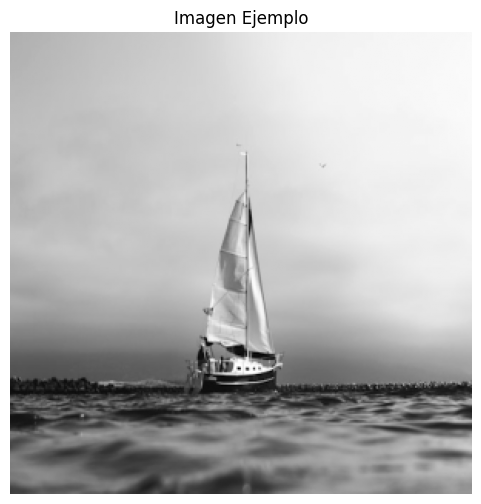

In [5]:
# Importamos imagen de ejemplo
path = 'img/barco.jpg'
img = cv2.imread(path, cv2.IMREAD_COLOR)
# Gris
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Redimensionamiento
img_resized = cv2.resize(img_gray, (300, 300), interpolation=cv2.INTER_AREA)

plt.figure(figsize=(6, 6))
plt.imshow(img_resized, cmap='gray')
plt.title('Imagen Ejemplo')
plt.axis('off')
plt.show()

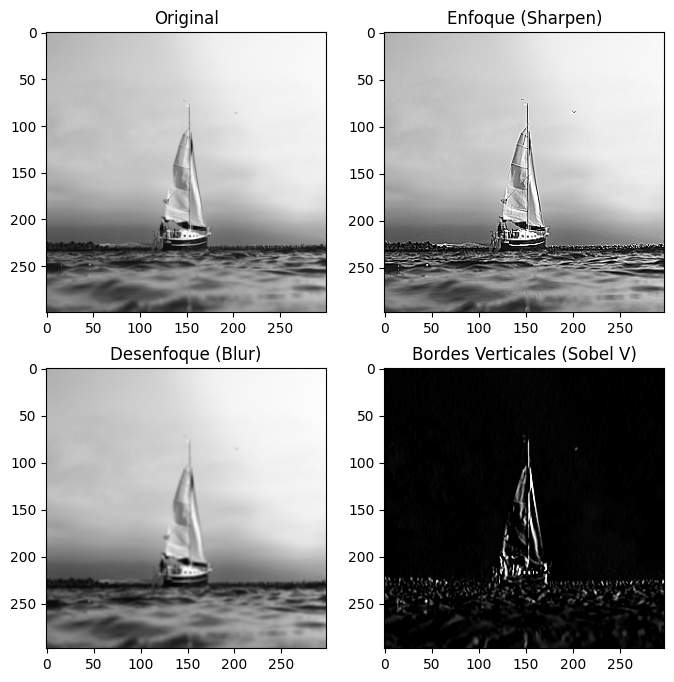

In [6]:
res_sharpen = convolucion_2d(img_resized, kernel_sharpen)
res_blur = convolucion_2d(img_resized, kernel_blur)
res_sobel = convolucion_2d(img_resized, kernel_sobel_v)

plt.figure(figsize=(8, 8))
plt.subplot(2, 2, 1); plt.imshow(img_resized, cmap='gray'); plt.title('Original')
plt.subplot(2, 2, 2); plt.imshow(res_sharpen, cmap='gray'); plt.title('Enfoque (Sharpen)')
plt.subplot(2, 2, 3); plt.imshow(res_blur, cmap='gray'); plt.title('Desenfoque (Blur)')
plt.subplot(2, 2, 4); plt.imshow(res_sobel, cmap='gray'); plt.title('Bordes Verticales (Sobel V)')
plt.show()

### CALLBACKS

In [7]:
def obtener_callbacks(nombre_modelo):
    # Devuelve EarlyStopping y ModelCheckpoint
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=3, restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=f"mejor_modelo_{nombre_modelo}.keras",
            save_best_only=True, monitor="val_loss"
        )
    ]

### DATASET: Cats vs Dogs

In [8]:
# Download latest version
path = kagglehub.dataset_download("birajsth/cats-and-dogs-filtered")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\LUIS PC\.cache\kagglehub\datasets\birajsth\cats-and-dogs-filtered\versions\1


In [9]:
PATH = os.path.join(path, 'cats_and_dogs_filtered')
train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')

In [10]:
BATCH_SIZE = 32
IMG_SIZE = (180, 180)
train_dataset  = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
    )
val_dataset    = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
    )


Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


### CNN manual

In [11]:
def build_cnn_manual():
    inputs = keras.Input(shape=(180, 180, 3))
    x = layers.Rescaling(1./255)(inputs)           # Normalización
    x = layers.Conv2D(32,  3, activation="relu")(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64,  3, activation="relu")(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu")(x); x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs, name="CNN_Manual")

In [12]:
model_manual = build_cnn_manual()
model_manual.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history_manual = model_manual.fit(train_dataset, epochs=15,
                                   validation_data=val_dataset,
                                   callbacks=obtener_callbacks("manual"))

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 452ms/step - accuracy: 0.5150 - loss: 0.6978 - val_accuracy: 0.6200 - val_loss: 0.6870
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 438ms/step - accuracy: 0.5820 - loss: 0.6726 - val_accuracy: 0.6420 - val_loss: 0.6411
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 501ms/step - accuracy: 0.6600 - loss: 0.6238 - val_accuracy: 0.6560 - val_loss: 0.6195
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 508ms/step - accuracy: 0.7265 - loss: 0.5443 - val_accuracy: 0.6990 - val_loss: 0.5765
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 493ms/step - accuracy: 0.7855 - loss: 0.4604 - val_accuracy: 0.7290 - val_loss: 0.5794
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 537ms/step - accuracy: 0.8425 - loss: 0.3571 - val_accuracy: 0.7200 - val_loss: 0.6187
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 495ms/step - accuracy: 0.8965 - loss: 0.2531 - val_accuracy: 0.7050 - val_loss: 0.8331


###  CNN REGULARIZADA: Data Augmentation + Dropout

In [13]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="DataAugmentation")


In [14]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="DataAugmentation")

def build_cnn_regularizada():
    inputs = keras.Input(shape=(180, 180, 3))
    x = data_augmentation(inputs) # Augmentation primero
    x = layers.Rescaling(1./255)(x)
    x = layers.Conv2D(32,  3, activation="relu")(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64,  3, activation="relu")(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu")(x); x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.5)(x) # Apaga 50% nodos para evitar overfitting
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs, name="CNN_Regularizada")

In [16]:
model_aumentation = build_cnn_regularizada()
model_aumentation.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history_manual = model_aumentation.fit(train_dataset, epochs=8,
                                   validation_data=val_dataset,
                                   callbacks=obtener_callbacks("manual"))

Epoch 1/8


63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 486ms/step - accuracy: 0.5005 - loss: 0.7037 - val_accuracy: 0.5480 - val_loss: 0.6921
Epoch 2/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 506ms/step - accuracy: 0.5545 - loss: 0.6874 - val_accuracy: 0.5620 - val_loss: 0.6868
Epoch 3/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 565ms/step - accuracy: 0.5855 - loss: 0.6766 - val_accuracy: 0.6330 - val_loss: 0.6506
Epoch 4/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 491ms/step - accuracy: 0.5715 - loss: 0.6812 - val_accuracy: 0.6110 - val_loss: 0.6784
Epoch 5/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 489ms/step - accuracy: 0.6040 - loss: 0.6654 - val_accuracy: 0.5940 - val_loss: 0.6620
Epoch 6/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 487ms/step - accuracy: 0.6450 - loss: 0.6342 - val_accuracy: 0.6500 - val_loss: 0.6168
Epoch 7/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 494ms/step - accuracy: 0.6700 - loss: 0.6101 - val_accuracy: 0.6390 - val_loss: 0.6278
Epoch 8/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 488ms/step - accuracy: 0.6945 - loss: 0.5907 - val_accuracy: 0.6380 - val

### TRANSFER LEARNING 

In [17]:
def build_transfer_model(base_arch="ResNet50V2"):
    base_model = keras.applications.ResNet50V2(
        weights="imagenet", include_top=False, input_shape=(180, 180, 3)
    )
    base_model.trainable = False  # Congelamos los pesos de ResNet
    preprocess = keras.applications.resnet_v2.preprocess_input

    inputs = keras.Input(shape=(180, 180, 3))
    x = data_augmentation(inputs)
    x = preprocess(x)
    x = base_model(x, training=False)             
    x = layers.GlobalAveragePooling2D()(x) 
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs, name=f"TransferLearning_{base_arch}")

In [19]:
model_TrLearning = build_cnn_regularizada()
model_TrLearning.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history_manual = model_TrLearning.fit(train_dataset, epochs=8,
                                   validation_data=val_dataset,
                                   callbacks=obtener_callbacks("model_TrLearning"))

Epoch 1/8


63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 479ms/step - accuracy: 0.4970 - loss: 0.7129 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 493ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 500ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 494ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 497ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 496ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 491ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 500ms/step - accuracy: 0.4690 - loss: 0.6932 - val_accuracy: 0.5000 - val

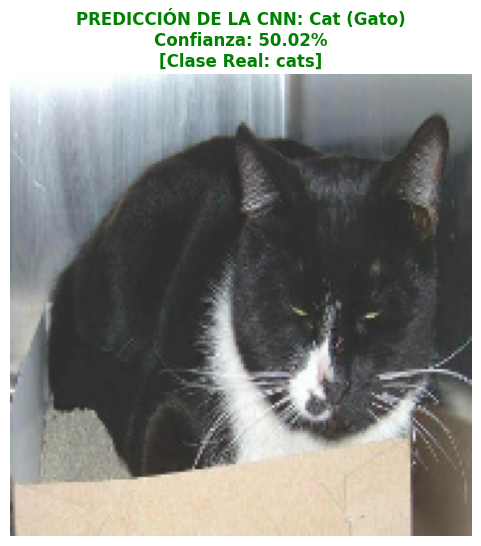

In [21]:
# 1. Extraemos un lote del set de validación para tomar una imagen de prueba
for imagenes_val, etiquetas_val in val_dataset.take(1):
    # Tomamos la primera imagen y su etiqueta real del lote
    img_individual = imagenes_val[1]
    etiqueta_real = etiquetas_val[1].numpy()
    break

# 2. EXPANDIR DIMENSIONES (Pasar de 3D a 4D para cumplir la regla de Keras)
# Pasa de (180, 180, 3) a (1, 180, 180, 3)
img_preparada = tf.expand_dims(img_individual, axis=0)

# 3. EJECUTAR LA INFERENCIA (PREDICT)
# predict() nos devuelve un arreglo con la probabilidad flotante
prediccion_cruda = model_TrLearning.predict(img_preparada, verbose=0)
probabilidad = prediccion_cruda[0][0]

# 4. INTERPRETACIÓN DEL SIGMOID (> 0.5 es Perro (1), <= 0.5 es Gato (0))
if probabilidad > 0.5:
    clase_predicha = "Dog (Perro)"
    confianza = probabilidad * 100
else:
    clase_predicha = "Cat (Gato)"
    confianza = (1 - probabilidad) * 100

nombres_clases = train_dataset.class_names
clase_real = nombres_clases[etiqueta_real]

# 5. VISUALIZACIÓN DEL RESULTADO EN PANTALLA
plt.figure(figsize=(6, 6))
plt.imshow(img_individual.numpy().astype("uint8"))

# Color del título: Verde si acertó, Rojo si se equivocó
color_titulo = 'green' if clase_predicha.lower().startswith(clase_real.lower()[:3]) else 'red'

plt.title(f"PREDICCIÓN DE LA CNN: {clase_predicha}\nConfianza: {confianza:.2f}%\n[Clase Real: {clase_real}]",
          color=color_titulo, fontsize=12, weight='bold')
plt.axis("off")
plt.show()

### XAI: GRAD-CAM (Gradient-weighted Class Activation Mapping)

Un problema fundamental al desarrollar aplicaciones de visión artificial es la interpretabilidad: ¿Por qué el clasificador interpretó que una imagen contenía un refrigerador, cuando lo único que se ve es un camión? Esto es especialmente relevante en casos de uso donde el aprendizaje profundo complementa la experiencia humana, como en el procesamiento de imágenes médicas. Este capítulo le familiarizará con diversas técnicas para visualizar lo que aprenden las redes neuronales convolucionales (ConvNets) y comprender las decisiones que toman.

A menudo se dice que los modelos de aprendizaje profundo son "cajas negras": aprenden representaciones difíciles de extraer y presentar de forma comprensible para el ser humano. Si bien esto es parcialmente cierto para ciertos tipos de modelos de aprendizaje profundo, definitivamente no lo es para las ConvNets. Las representaciones aprendidas por las ConvNets son muy fáciles de visualizar, en gran parte porque son representaciones de conceptos visuales. Desde 2013, se ha desarrollado una amplia gama de técnicas para visualizar e interpretar estas representaciones. No las revisaremos todas, pero cubriremos tres de las más accesibles y útiles:

In [84]:
# Tomar un lote del conjunto de validación
for imagenes_val, etiquetas_val in val_dataset.take(1):
    # Índice aleatorio dentro del lote (tamaño 32)
    idx = np.random.randint(0, imagenes_val.shape[0])
    img_individual = imagenes_val[idx]
    etiqueta_real  = etiquetas_val[idx].numpy()
    break

# Expandir a (1, 180, 180, 3) — Keras exige dimensión de batch
img_array = tf.expand_dims(img_individual, axis=0).numpy()

print(f"Imagen idx={idx} | Clase real: {nombres_clases[etiqueta_real]}")

Imagen idx=8 | Clase real: cats


In [57]:
def visualizar_gradcam_manual(modelo, nombre_capa, img_array, nombres_clases):
    """
    modelo       : model_manual (o cualquier CNN entrenada con TF/Keras)
    nombre_capa  : última capa Conv2D antes del Flatten (ej. "Conv_3")
    img_array    : numpy array (1, H, W, 3)  ← usa el del paso 1
    nombres_clases: lista ["cats","dogs"] del dataset
    """
    # Sub-modelo que expone la capa conv + salida final
    grad_model = keras.Model(
        inputs=modelo.inputs,
        outputs=[modelo.get_layer(nombre_capa).output, modelo.output]
    )

    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_out, pred = grad_model(img_tensor, training=False)
        tape.watch(conv_out)
        clase_score = pred[:, 0]

    # Gradiente del score respecto a las activaciones conv
    grads   = tape.gradient(clase_score, conv_out)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(weights * conv_out, axis=-1)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap_np = heatmap.numpy().squeeze()

    # Superponer sobre imagen original
    h, w = img_array.shape[1], img_array.shape[2]
    hm_resize = cv2.resize(heatmap_np, (w, h))
    hm_color  = cv2.cvtColor(
        cv2.applyColorMap(np.uint8(255 * hm_resize), cv2.COLORMAP_JET),
        cv2.COLOR_BGR2RGB
    )
    img_orig = img_array[0].astype("uint8")
    superpos = cv2.addWeighted(img_orig, 0.6, hm_color, 0.4, 0)

    # Decisión final
    score     = pred.numpy()[0][0]
    etiqueta  = nombres_clases[1] if score > 0.5 else nombres_clases[0]
    confianza = score if score > 0.5 else (1 - score)

    # Visualización
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(img_orig)
    plt.title("Original"); plt.axis("off")

    plt.subplot(1, 3, 2); plt.matshow(heatmap_np, fignum=False, cmap="viridis")
    plt.title("Heatmap crudo"); plt.axis("off")

    plt.subplot(1, 3, 3); plt.imshow(superpos)
    color = "green" if etiqueta == nombres_clases[etiqueta_real] else "red"
    plt.title(f"Grad-CAM\n{etiqueta} ({confianza*100:.1f}%)", color=color)
    plt.axis("off")

    plt.suptitle(f"Clase real: {nombres_clases[etiqueta_real]}", fontsize=13)
    plt.tight_layout(); plt.show()

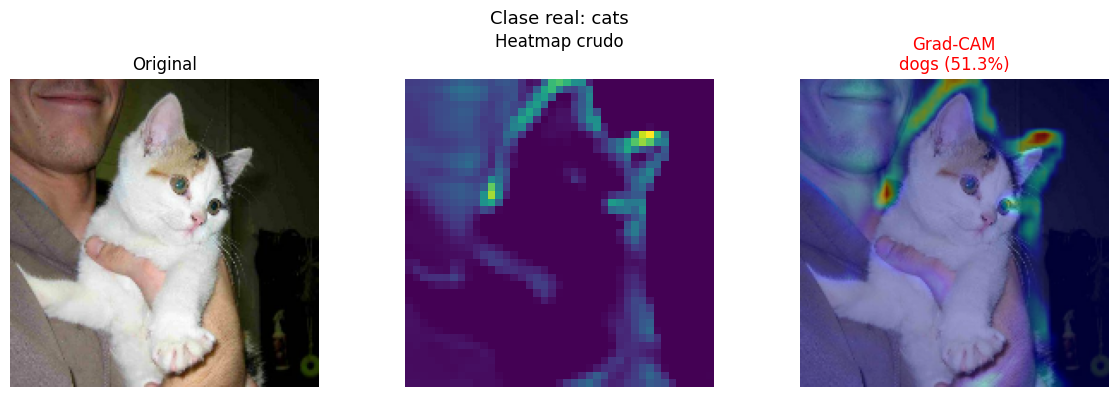

In [85]:
visualizar_gradcam_manual(model_aumentation, "conv2d_8", img_array, nombres_clases)

## RNNs — SERIES TEMPORALES (DATASET JENA CLIMATE)

### CARGA Y EXPLORACIÓN DEL DATASET (Jena Climate 2009-2016)

In [90]:
df = pd.read_csv("data/jena_climate_2009_2016.csv")
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


### PREPARACIÓN: DIVISIÓN CRONOLÓGICA Y NORMALIZACIÓN

División: Train 50% | Val 25% | Test 25% (en orden de tiempo).

Normalización con media y std calculados solo con train aplicados a los 3 sets.

In [102]:
cantidad_datos = len(df)
num_train = cantidad_datos // 2  # Entenamiento
num_val_test   = cantidad_datos // 4  # Validación y test
# el resto va automáticamente a test


In [106]:
target    = df["T (degC)"].values          # Variable a predecir
raw_data  = df.drop("Date Time", axis=1).values
mean_target, std_target = raw_data[:num_train].mean(axis=0), raw_data[:num_val_test].std(axis=0)
raw_data  = (raw_data - mean_target) / std_target

### GENERADOR DE VENTANAS DESLIZANTES

In [101]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1) # Desfase de 24 horas en el futuro
batch_size = 256

In [104]:
# Creación de los tres datasets estructurados
train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=target[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=target[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    batch_size=batch_size,
    start_index=num_train,
    end_index=num_train + num_val_test
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=target[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    batch_size=batch_size,
    start_index=num_train + num_val_test
)

In [105]:
# Inspección del primer lote (Batch) generado 
for samples, targets_batch in train_dataset.take(1):
    print("--- Dimensiones de los Tensores Generados ---")
    print(f"Forma del lote de entrada (X): {samples.shape} -> (Batch, Timesteps, Features)")
    print(f"Forma del lote de salida  (y): {targets_batch.shape} -> (Batch,)")
    break

--- Dimensiones de los Tensores Generados ---
Forma del lote de entrada (X): (256, 120, 14) -> (Batch, Timesteps, Features)
Forma del lote de salida  (y): (256,) -> (Batch,)


### MLP y CNN 1D (modelos estáticos de referencia)

In [121]:
model_mlp = models.Sequential([
    layers.Flatten(input_shape=(120, 14)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])
model_mlp.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_mlp = model_mlp.fit(train_dataset, epochs=10,
                             validation_data=val_dataset,
                             callbacks=[keras.callbacks.ModelCheckpoint("jena_mlp.keras", save_best_only=True)])

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 12.2927 - mae: 2.7090 - val_loss: 10.4589 - val_mae: 2.5442
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 8.8229 - mae: 2.3351 - val_loss: 10.0229 - val_mae: 2.4907
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 8.1394 - mae: 2.2424 - val_loss: 10.3669 - val_mae: 2.5340
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7.6797 - mae: 2.1783 - val_loss: 12.1300 - val_mae: 2.7440
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 7.3617 - mae: 2.1346 - val_loss: 10.6201 - val_mae: 2.5664
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.1428 - mae: 2.1026 - val_loss: 11.3876 - val_mae: 2.6564
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 6.9486 - mae: 2.0735 - val_loss: 10.9268 - val_mae: 2.6084
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 6.7945 - mae: 2.0511 - val_loss: 11.0394 - val_mae: 2.6284
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/

In [122]:
model_cnn = models.Sequential([
    layers.Conv1D(8, 24, activation="relu", input_shape=(120, 14)),
    layers.MaxPooling1D(2),
    layers.Conv1D(8, 12, activation="relu"),
    layers.GlobalMaxPooling1D(),
    layers.Dense(1)
])
model_cnn.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_cnn = model_cnn.fit(train_dataset, epochs=10,
                             validation_data=val_dataset,
                             callbacks=[keras.callbacks.ModelCheckpoint("jena_cnn.keras", save_best_only=True)])

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 21.9032 - mae: 3.6972 - val_loss: 18.8756 - val_mae: 3.4227
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 16.7004 - mae: 3.2369 - val_loss: 18.7289 - val_mae: 3.3929
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 15.0395 - mae: 3.0677 - val_loss: 19.9913 - val_mae: 3.5160
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - loss: 14.1822 - mae: 2.9749 - val_loss: 20.9291 - val_mae: 3.5916
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 13.6267 - mae: 2.9154 - val_loss: 21.1706 - val_mae: 3.6637
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - loss: 13.1983 - mae: 2.8695 - val_loss: 20.4841 - val_mae: 3.5919
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 12.8884 - mae: 2.8354 - val_loss: 22.2193 - val_mae: 3.7653
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 12.6254 - mae: 2.8040 - val_loss: 23.9359 - val_mae: 3.8841
Epoch 9/10
819/819 ━━━━━

### SIMPLE RNN

In [126]:
model_rnn = models.Sequential([
    layers.SimpleRNN(16, input_shape=(120, 14)),
    layers.Dense(1)
])
model_rnn.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_rnn = model_rnn.fit(train_dataset, epochs=8,
                             validation_data=val_dataset,
                             callbacks=[keras.callbacks.ModelCheckpoint("jena_rnn.keras", save_best_only=True)])

Epoch 1/8


c:\IBERO\A2Verano\ML2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 42.8343 - mae: 4.7952 - val_loss: 12.5708 - val_mae: 2.6544
Epoch 2/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 11.2546 - mae: 2.6053 - val_loss: 9.3349 - val_mae: 2.3801
Epoch 3/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 10.3600 - mae: 2.5076 - val_loss: 9.1698 - val_mae: 2.3593
Epoch 4/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 10.1989 - mae: 2.4876 - val_loss: 9.1328 - val_mae: 2.3566
Epoch 5/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 10.1196 - mae: 2.4775 - val_loss: 9.1355 - val_mae: 2.3572
Epoch 6/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 10.0636 - mae: 2.4702 - val_loss: 9.0440 - val_mae: 2.3452
Epoch 7/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 10.0072 - mae: 2.4638 - val_loss: 9.0517 - val_mae: 2.3479
Epoch 8/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 9.9487 - mae: 2.4574 - val_loss: 9.1780 - val_mae: 2.3590


### LSTM — Long Short-Term Memory

In [127]:
model_lstm = models.Sequential([
    layers.LSTM(32, input_shape=(120, 14)),
    layers.Dense(1)
])
model_lstm.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_lstm = model_lstm.fit(train_dataset, epochs=8,
                               validation_data=val_dataset,
                               callbacks=[keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)])

Epoch 1/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - loss: 24.6230 - mae: 3.5256 - val_loss: 9.4942 - val_mae: 2.3810
Epoch 2/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 58s 70ms/step - loss: 9.0379 - mae: 2.3471 - val_loss: 9.5903 - val_mae: 2.4167
Epoch 3/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 70s 86ms/step - loss: 8.1238 - mae: 2.2278 - val_loss: 9.7168 - val_mae: 2.4399
Epoch 4/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 70s 85ms/step - loss: 7.6697 - mae: 2.1594 - val_loss: 10.1544 - val_mae: 2.4956
Epoch 5/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 69s 84ms/step - loss: 7.1921 - mae: 2.0916 - val_loss: 10.4192 - val_mae: 2.5457
Epoch 6/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 66s 81ms/step - loss: 6.7821 - mae: 2.0288 - val_loss: 10.6666 - val_mae: 2.5508
Epoch 7/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 62s 76ms/step - loss: 6.4786 - mae: 1.9803 - val_loss: 11.3091 - val_mae: 2.6253
Epoch 8/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 56s 68ms/step - loss: 6.1929 - mae: 1.9333 - val_loss: 11.9205 - val_mae: 2.6997


In [128]:
model_lstm_drop = models.Sequential([
    layers.LSTM(32, dropout=0.2, recurrent_dropout=0.2, input_shape=(120, 14)),
    layers.Dense(1)
])
model_lstm_drop.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_lstm_drop = model_lstm_drop.fit(train_dataset, epochs=8,
                                         validation_data=val_dataset,
                                         callbacks=[keras.callbacks.ModelCheckpoint("jena_lstm_drop.keras", save_best_only=True)])

Epoch 1/8


c:\IBERO\A2Verano\ML2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - loss: 23.9548 - mae: 3.5417 - val_loss: 8.9823 - val_mae: 2.3192
Epoch 2/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 10.8785 - mae: 2.5791 - val_loss: 8.9693 - val_mae: 2.3163
Epoch 3/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 10.2469 - mae: 2.5014 - val_loss: 8.9371 - val_mae: 2.3087
Epoch 4/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 66ms/step - loss: 9.8557 - mae: 2.4531 - val_loss: 8.8589 - val_mae: 2.2977
Epoch 5/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 66ms/step - loss: 9.6235 - mae: 2.4243 - val_loss: 9.0045 - val_mae: 2.3215
Epoch 6/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 64ms/step - loss: 9.4463 - mae: 2.4039 - val_loss: 9.0485 - val_mae: 2.3259
Epoch 7/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 64ms/step - loss: 9.2673 - mae: 2.3832 - val_loss: 9.0673 - val_mae: 2.3288
Epoch 8/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 64ms/step - loss: 9.1138 - mae: 2.3657 - val_loss: 8.8725 - val_mae: 2.3092


### GRU APILADO (Stacked GRU)

In [129]:
model_gru = models.Sequential([
    layers.GRU(32, recurrent_dropout=0.5, return_sequences=True, input_shape=(120, 14)),
    layers.GRU(16, recurrent_dropout=0.5),
    layers.Dense(1)
])
model_gru.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_gru = model_gru.fit(train_dataset, epochs=8,
                             validation_data=val_dataset,
                             callbacks=[keras.callbacks.ModelCheckpoint("jena_gru.keras", save_best_only=True)])

Epoch 1/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 96s 114ms/step - loss: 40.3400 - mae: 4.5871 - val_loss: 12.7965 - val_mae: 2.6807
Epoch 2/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 113s 138ms/step - loss: 10.6439 - mae: 2.5294 - val_loss: 9.2368 - val_mae: 2.3485
Epoch 3/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 113s 138ms/step - loss: 9.4279 - mae: 2.3954 - val_loss: 8.8485 - val_mae: 2.2995
Epoch 4/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 113s 138ms/step - loss: 8.9974 - mae: 2.3422 - val_loss: 9.0309 - val_mae: 2.3166
Epoch 5/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 112s 137ms/step - loss: 8.6542 - mae: 2.3021 - val_loss: 9.3793 - val_mae: 2.3647
Epoch 6/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 115s 140ms/step - loss: 8.3636 - mae: 2.2656 - val_loss: 8.8058 - val_mae: 2.2918
Epoch 7/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 114s 139ms/step - loss: 8.1202 - mae: 2.2321 - val_loss: 9.1026 - val_mae: 2.3313
Epoch 8/8
819/819 ━━━━━━━━━━━━━━━━━━━━ 113s 138ms/step - loss: 7.8764 - mae: 2.2007 - val_loss: 8.7868 - val_mae: 2.2840


EVALUACIÓN

In [130]:
print(f"MLP {model_mlp.evaluate(test_dataset, verbose=0)[1] * std_target:.2f} °C")
print(f"CNN 1D {model_cnn.evaluate(test_dataset, verbose=0)[1] * std_target:.2f} °C")
print(f"SimpleRNN {model_rnn.evaluate(test_dataset, verbose=0)[1] * std_target:.2f} °C")
print(f"LSTM {model_lstm.evaluate(test_dataset, verbose=0)[1] * std_target:.2f} °C")
print(f"LSTM drop {model_lstm_drop.evaluate(test_dataset, verbose=0)[1] * std_target:.2f} °C")
print(f"GRU apilado {model_gru.evaluate(test_dataset, verbose=0)[1] * std_target:.2f} °C")

MLP 82.91 °C
CNN 1D 405.71 °C
SimpleRNN 21.84 °C
LSTM 24.47 °C
LSTM drop 21.73 °C
GRU apilado 21.24 °C
